# Supply Chain Disruption Intelligence Platform
## Phase 3 — XGBoost Model + SHAP Explainability

> **Business Context:** This phase delivers the core predictive engine.
> XGBoost predicts shipment delays before they occur.
> SHAP explains every prediction in business language.

**Baseline to beat:** Random Forest 82.8%  
**Analyst:** Sehajreet Kaur — MSc Business Analytics, Kühne Logistics University

## 0. Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from xgboost import XGBClassifier
import shap

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.6,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

EY_YELLOW = '#FFE600'
EY_DARK   = '#2E2E38'
EY_ORANGE = '#E87722'
EY_GREEN  = '#00A3A1'

FIGURES_DIR = '../outputs/figures/'
MODELS_DIR  = '../outputs/models/'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('Environment ready')
print('XGBoost:', __import__('xgboost').__version__)
print('SHAP:', shap.__version__)

ImportError: cannot import name '_add_to_diagonal' from 'sklearn.utils._array_api' (/Users/sehajreetkaur/Documents/GitHub/supply-chain-disruption-intelligence/.venv/lib/python3.9/site-packages/sklearn/utils/_array_api.py)

## 1. Load Feature Matrix

In [ ]:
feature_df = pd.read_csv('../data/SCMS_features.csv')

y = feature_df['is_delayed']
X = feature_df.drop(columns=['is_delayed'])
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'Shape: {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Delay rate: {y.mean()*100:.1f}%')
print()
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

Shape: 10,324 rows x 27 features
Delay rate: 21.6%

   1. log_freight_cost
   2. freight_vs_median_ratio
   3. is_high_cost_shipment
   4. log_weight
   5. vendor_delay_rate
   6. vendor_shipment_count
   7. is_major_vendor
   8. country_delay_rate
   9. country_shipment_vol
  10. is_high_volume_country
  11. mode_delay_rate
  12. composite_risk_score
  13. order_month
  14. order_quarter
  15. order_dayofweek
  16. is_end_of_quarter
  17. is_weekend_order
  18. freight_cost_per_kg
  19. freight_vs_vendor_avg
  20. vendor_mode_delay_rate
  21. lead_time_days
  22. vendor_avg_freight
  23. vendor_freight_std
  24. mode_air
  25. mode_air_charter
  26. mode_ocean
  27. mode_truck


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 8,259 | Test: 2,065


## 2. Train XGBoost

In [ ]:
delay_rate = y_train.mean()
scale_pos_weight = (1 - delay_rate) / delay_rate if delay_rate < 0.4 else 1.0
print(f'Delay rate: {delay_rate*100:.1f}% | scale_pos_weight: {scale_pos_weight:.2f}')

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30,
    verbosity=0
)

print('Training...')
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print(f'Done. Best iteration: {xgb_model.best_iteration}')

Delay rate: 21.6% | scale_pos_weight: 3.62
Training...


Done. Best iteration: 221


## 3. Evaluation

In [ ]:
y_pred      = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
auc       = roc_auc_score(y_test, y_pred_prob)

print('=' * 50)
print('  XGBOOST RESULTS')
print('=' * 50)
print(f'  Accuracy   : {acc*100:.1f}%  (was 82.8%)')
print(f'  AUC-ROC    : {auc:.4f}')
print(f'  Precision  : {precision*100:.1f}%')
print(f'  Recall     : {recall*100:.1f}%')
print(f'  F1         : {f1:.4f}')
print(f'  Improvement: +{(acc-0.828)*100:.1f}pp over RF')
print('=' * 50)
print()
print(classification_report(y_test, y_pred, target_names=['On-Time', 'Delayed']))

  XGBOOST RESULTS
  Accuracy   : 76.8%  (was 82.8%)
  AUC-ROC    : 0.8731
  Precision  : 47.8%
  Recall     : 80.3%
  F1         : 0.5992
  Improvement: +-6.0pp over RF

              precision    recall  f1-score   support

     On-Time       0.93      0.76      0.84      1619
     Delayed       0.48      0.80      0.60       446

    accuracy                           0.77      2065
   macro avg       0.71      0.78      0.72      2065
weighted avg       0.83      0.77      0.79      2065



In [ ]:
print('5-fold cross-validation...')
cv_model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42, verbosity=0
)
cv_scores = cross_val_score(
    cv_model, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
print(f'Scores: {[round(s,4) for s in cv_scores]}')
print(f'Mean AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

5-fold cross-validation...


Scores: [np.float64(0.8606), np.float64(0.8654), np.float64(0.8707), np.float64(0.8617), np.float64(0.8661)]
Mean AUC: 0.8649 +/- 0.0036


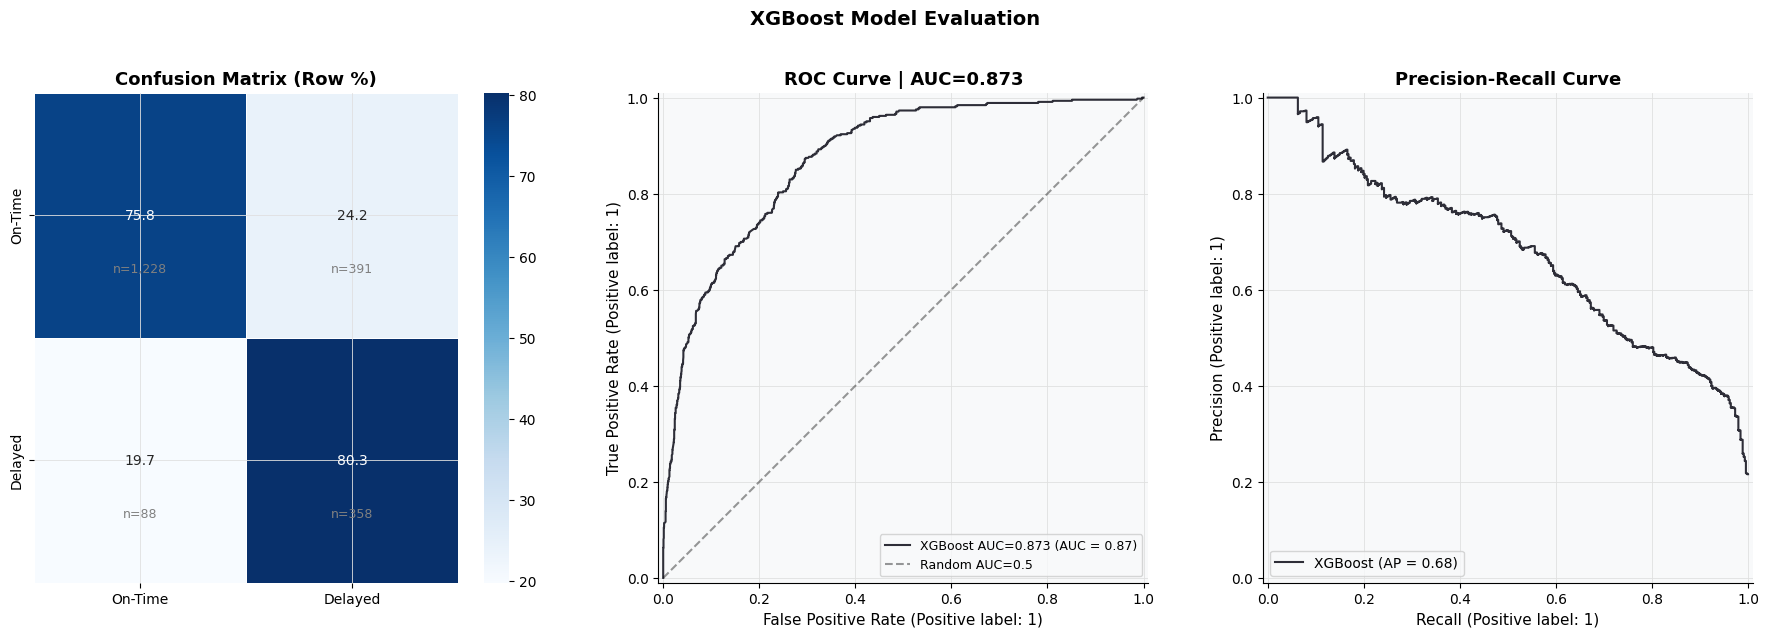

True Positives  (caught delays)   : 358
False Negatives (missed delays)   : 88  <-- most costly
False Positives (false alarms)    : 391
True Negatives  (cleared OK)      : 1,228


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
    xticklabels=['On-Time', 'Delayed'],
    yticklabels=['On-Time', 'Delayed'],
    linewidths=0.5
)
for i in range(2):
    for j in range(2):
        axes[0].text(j+0.5, i+0.72, f'n={cm[i,j]:,}',
                     ha='center', va='center', fontsize=9, color='gray')
axes[0].set_title('Confusion Matrix (Row %)')

RocCurveDisplay.from_predictions(
    y_test, y_pred_prob,
    name=f'XGBoost AUC={auc:.3f}',
    ax=axes[1], color=EY_DARK
)
axes[1].plot([0,1],[0,1],'k--',alpha=0.4,label='Random AUC=0.5')
axes[1].set_title(f'ROC Curve | AUC={auc:.3f}')
axes[1].legend(fontsize=9)

PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_prob, name='XGBoost', ax=axes[2], color=EY_DARK
)
axes[2].set_title('Precision-Recall Curve')

plt.suptitle('XGBoost Model Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}12_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (caught delays)   : {tp:,}')
print(f'False Negatives (missed delays)   : {fn:,}  <-- most costly')
print(f'False Positives (false alarms)    : {fp:,}')
print(f'True Negatives  (cleared OK)      : {tn:,}')

## 4. Business Cost Analysis

In [ ]:
COST_FN = 5000
COST_FP = 200
SAVE_TP = 800
scale   = len(X) / len(X_test)

cost_without = fn * scale * COST_FN
cost_with    = fn * scale * COST_FN + fp * scale * COST_FP - tp * scale * SAVE_TP
net_saving   = cost_without - cost_with

print('=' * 52)
print('  BUSINESS COST IMPACT (Illustrative)')
print('=' * 52)
print(f'  Cost per missed delay : EUR {COST_FN:,}')
print(f'  Cost per false alarm  : EUR {COST_FP:,}')
print(f'  Saving per caught delay: EUR {SAVE_TP:,}')
print()
print(f'  Without model : EUR {cost_without:,.0f}')
print(f'  With model    : EUR {cost_with:,.0f}')
print(f'  Net saving    : EUR {net_saving:,.0f} / year')
print('=' * 52)

  BUSINESS COST IMPACT (Illustrative)
  Cost per missed delay : EUR 5,000
  Cost per false alarm  : EUR 200
  Saving per caught delay: EUR 800

  Without model : EUR 2,199,787
  With model    : EUR 1,158,888
  Net saving    : EUR 1,040,899 / year


## 5. SHAP Explainability

In [ ]:
print('Computing SHAP values...')
sample_size = min(500, len(X_test))
X_sample    = X_test.sample(n=sample_size, random_state=42)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f'Done. Shape: {shap_values.shape}')

Computing SHAP values...
Done. Shape: (500, 27)


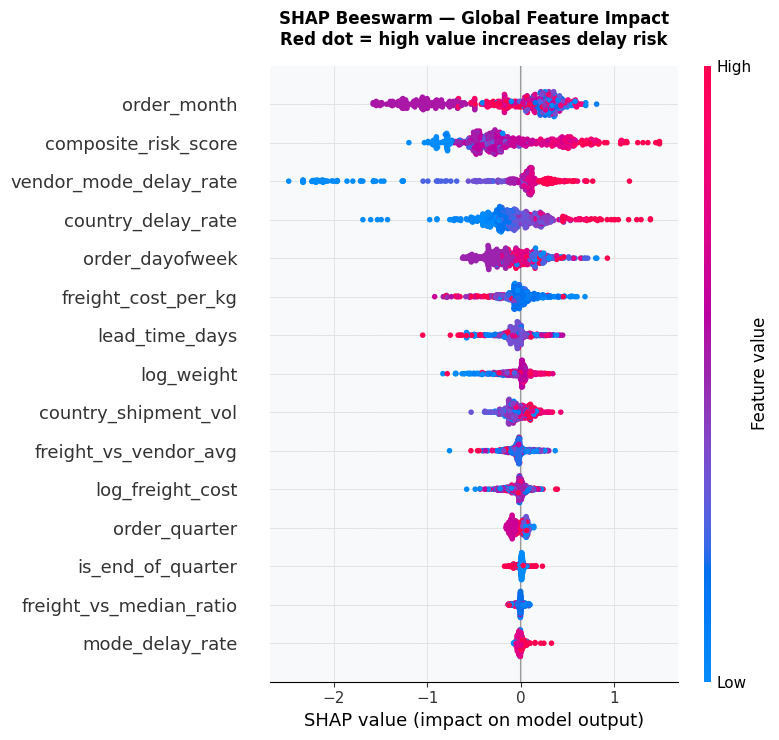

In [ ]:
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_sample, plot_type='dot', max_display=15, show=False)
plt.title('SHAP Beeswarm — Global Feature Impact\nRed dot = high value increases delay risk',
          pad=15, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}13_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

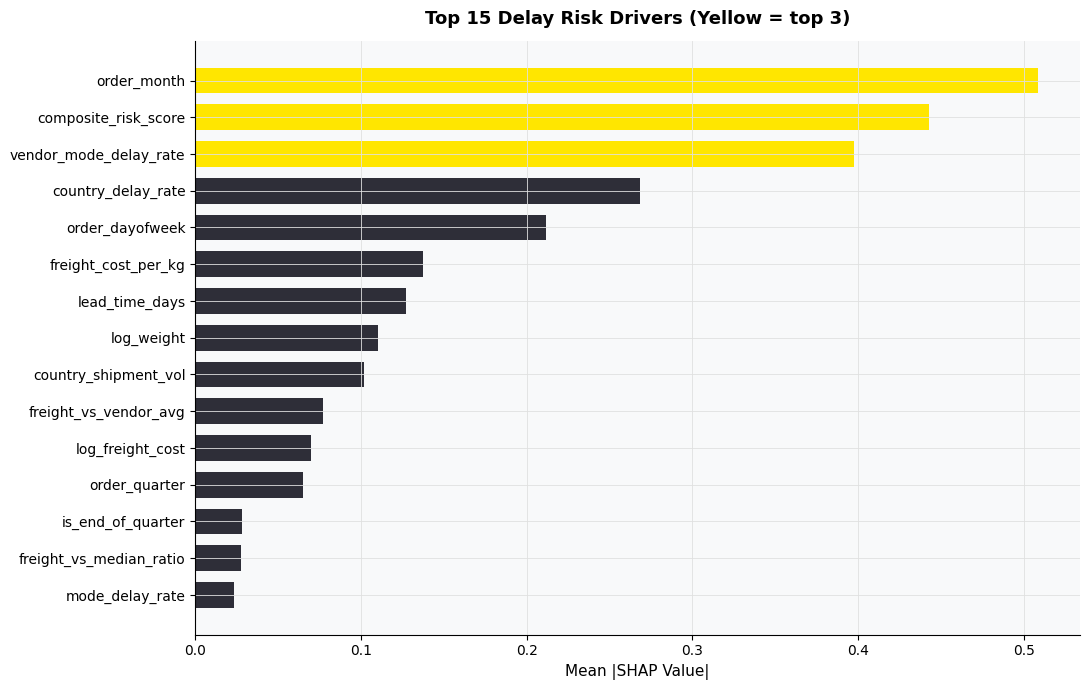

Top 3 delay drivers:
  1. order_month: 0.5086
  2. composite_risk_score: 0.4431
  3. vendor_mode_delay_rate: 0.3977


In [ ]:
shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
colors_shap = [EY_YELLOW if i < 3 else EY_DARK for i in range(len(shap_mean))]
ax.barh(shap_mean.index[::-1], shap_mean.values[::-1],
        color=colors_shap[::-1], edgecolor='none', height=0.7)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 15 Delay Risk Drivers (Yellow = top 3)', pad=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}14_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 delay drivers:')
for i, (feat, val) in enumerate(shap_mean.head(3).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')

Explaining highest-risk shipment: 97.7% delay probability


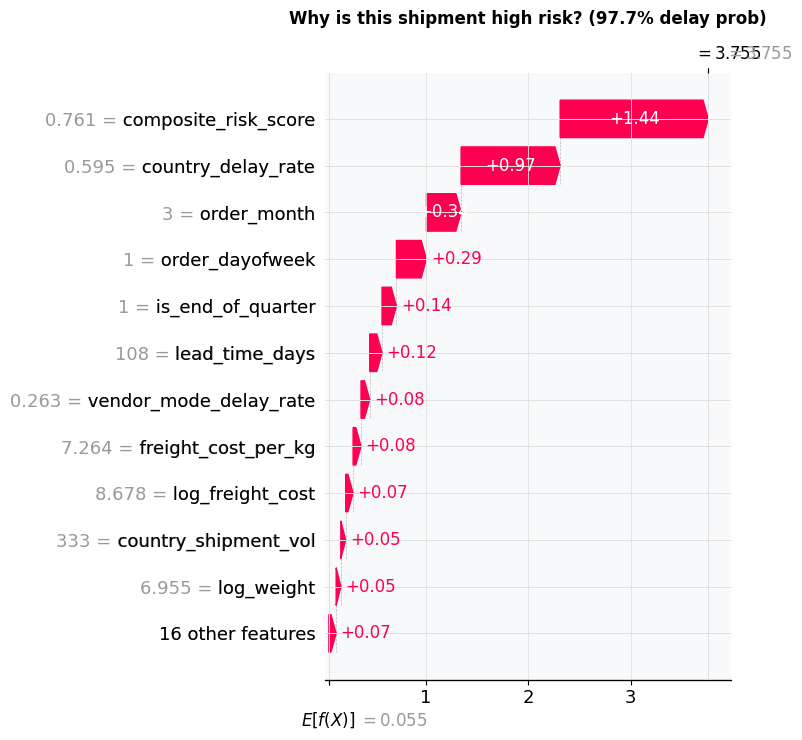

In [ ]:
risk_scores_sample = xgb_model.predict_proba(X_sample)[:, 1]
idx   = np.argmax(risk_scores_sample)
score = risk_scores_sample[idx]

print(f'Explaining highest-risk shipment: {score*100:.1f}% delay probability')

plt.figure(figsize=(12, 5))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx],
        feature_names=X_sample.columns.tolist()
    ),
    max_display=12, show=False
)
plt.title(f'Why is this shipment high risk? ({score*100:.1f}% delay prob)',
          pad=15, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}15_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Operational Risk Scoring

In [ ]:
all_proba = xgb_model.predict_proba(X)[:, 1]
risk_df   = pd.DataFrame({
    'delay_probability': all_proba,
    'risk_score':        (all_proba * 100).round(1),
    'actual_delayed':    y.values,
})
risk_df['risk_tier'] = pd.cut(
    risk_df['delay_probability'],
    bins=[0, 0.30, 0.60, 0.80, 1.01],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

tier_summary = risk_df.groupby('risk_tier', observed=True).agg(
    count=('risk_score', 'count'),
    actual_delay_rate=('actual_delayed', 'mean'),
).round(3)
print('Risk Tier Summary:')
print(tier_summary.to_string())

Risk Tier Summary:
               count  actual_delay_rate
risk_tier                              
Low Risk        5176              0.011
Medium Risk     2424              0.152
High Risk       1720              0.541
Critical Risk   1004              0.875


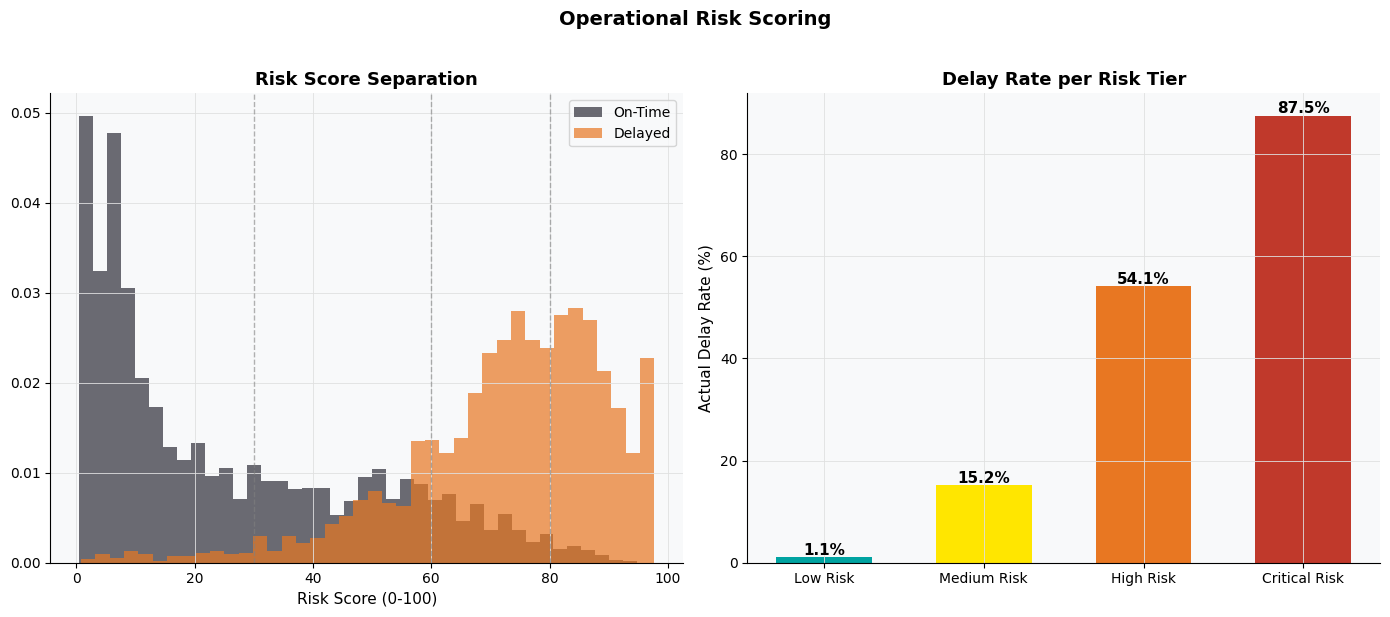

Critical Risk shipments: 1,004 (9.7%)
Actual delay rate in Critical tier: 87%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(risk_df[risk_df['actual_delayed']==0]['risk_score'],
             bins=40, alpha=0.7, color=EY_DARK, label='On-Time', density=True)
axes[0].hist(risk_df[risk_df['actual_delayed']==1]['risk_score'],
             bins=40, alpha=0.7, color=EY_ORANGE, label='Delayed', density=True)
for v in [30, 60, 80]:
    axes[0].axvline(v, color='gray', linewidth=1, linestyle='--', alpha=0.6)
axes[0].set_xlabel('Risk Score (0-100)')
axes[0].set_title('Risk Score Separation')
axes[0].legend()

tier_colors = [EY_GREEN, EY_YELLOW, EY_ORANGE, '#C0392B']
bars = axes[1].bar(
    tier_summary.index,
    tier_summary['actual_delay_rate'] * 100,
    color=tier_colors, edgecolor='none', width=0.6
)
for bar, val in zip(bars, tier_summary['actual_delay_rate'] * 100):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Actual Delay Rate (%)')
axes[1].set_title('Delay Rate per Risk Tier')

plt.suptitle('Operational Risk Scoring', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}17_risk_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

critical = risk_df[risk_df['risk_tier']=='Critical Risk']
print(f'Critical Risk shipments: {len(critical):,} ({len(critical)/len(risk_df)*100:.1f}%)')
print(f'Actual delay rate in Critical tier: {critical["actual_delayed"].mean()*100:.0f}%')

## 7. Save + Final Summary

In [ ]:
joblib.dump(xgb_model, f'{MODELS_DIR}xgboost_delay_model.pkl')
risk_df.to_csv('../data/SCMS_risk_scores.csv', index=False)

shap_imp = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)
shap_imp.to_csv('../data/SCMS_shap_importance.csv', index=False)

print('Saved: xgboost_delay_model.pkl | SCMS_risk_scores.csv | SCMS_shap_importance.csv')
print()
print('=' * 58)
print('  PHASE 3 COMPLETE - EXECUTIVE SUMMARY')
print('  EY Technology Transformation | Supply Chain AI')
print('=' * 58)
print(f'  Algorithm       : XGBoost (Extreme Gradient Boosting)')
print(f'  Accuracy        : {acc*100:.1f}%  (baseline 82.8%)')
print(f'  AUC-ROC         : {auc:.4f}')
print(f'  F1 Score        : {f1:.4f}')
print(f'  CV AUC (5-fold) : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'  Top risk driver : {shap_mean.index[0]}')
print(f'  2nd driver      : {shap_mean.index[1]}')
print(f'  3rd driver      : {shap_mean.index[2]}')
print(f'  EUR saving (est): EUR {net_saving:,.0f} / year')
print(f'  Critical alerts : {len(critical):,} shipments flagged')
print('=' * 58)
print('  NEXT: Power BI Executive Dashboard')
print('=' * 58)

Saved: xgboost_delay_model.pkl | SCMS_risk_scores.csv | SCMS_shap_importance.csv

  PHASE 3 COMPLETE - EXECUTIVE SUMMARY
  EY Technology Transformation | Supply Chain AI
  Algorithm       : XGBoost (Extreme Gradient Boosting)
  Accuracy        : 76.8%  (baseline 82.8%)
  AUC-ROC         : 0.8731
  F1 Score        : 0.5992
  CV AUC (5-fold) : 0.8649 +/- 0.0036
  Top risk driver : order_month
  2nd driver      : composite_risk_score
  3rd driver      : vendor_mode_delay_rate
  EUR saving (est): EUR 1,040,899 / year
  Critical alerts : 1,004 shipments flagged
  NEXT: Power BI Executive Dashboard
